# 📰 AI-Based Fake News Detection — Week 1 EDA
## Exploratory Data Analysis

**Goal:** Understand the dataset before building any model.

Sections:
1. Dataset overview & class balance  
2. Text length analysis  
3. Word frequency & Word Cloud  
4. Subject / category breakdown  
5. Preprocessing preview

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))   # so we can import from src/

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud

# ── project modules ───────────────────────────────────────────────────────────
from src.load_data  import load_data, get_data_summary
from src.preprocess import preprocess_dataframe

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
print("Imports OK ✓")

Imports OK ✓


## 1. Dataset Overview

In [2]:
df = load_data()
summary = get_data_summary(df)

print(f"Shape           : {df.shape}")
print(f"Total articles  : {summary['total_articles']:,}")
print(f"Fake (label=1)  : {summary['fake_count']:,}")
print(f"Real (label=0)  : {summary['real_count']:,}")
print(f"Missing text    : {summary['missing_text']}")
print(f"\nColumns         : {summary['columns']}")
df.head()

Shape           : (44898, 5)
Total articles  : 44,898
Fake (label=1)  : 23,481
Real (label=0)  : 21,417
Missing text    : 0

Columns         : ['title', 'text', 'subject', 'date', 'label']


,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",1
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",0
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",0
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",1
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",0


## 2. Class Balance

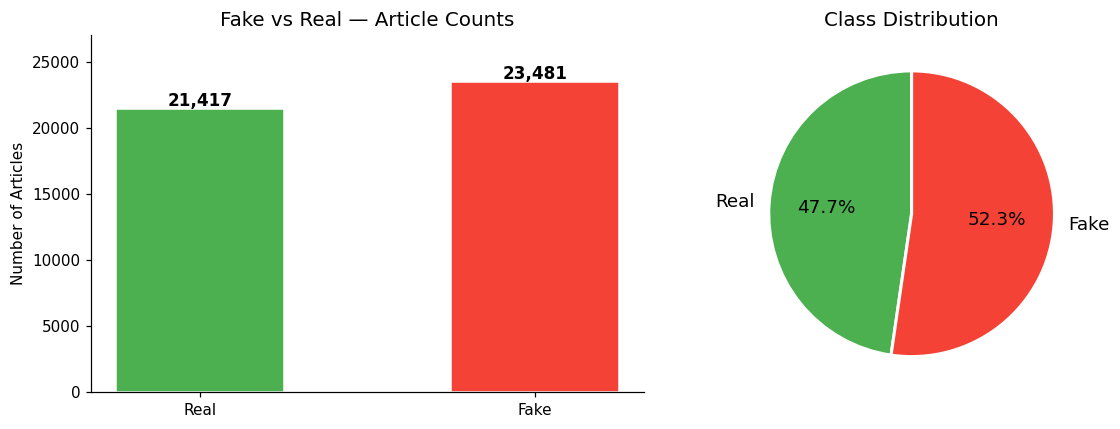


Class ratio (Fake/Real): 1.096


In [3]:
counts = df["label"].value_counts().sort_index()
labels = ["Real", "Fake"]
colors = ["#4CAF50", "#F44336"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Bar chart
axes[0].bar(labels, counts.values, color=colors, width=0.5, edgecolor="white")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f"{v:,}", ha="center", fontsize=11, fontweight="bold")
axes[0].set_title("Fake vs Real — Article Counts", fontsize=13)
axes[0].set_ylabel("Number of Articles")
axes[0].set_ylim(0, counts.max() * 1.15)

# Pie chart
axes[1].pie(
    counts.values, labels=labels, colors=colors,
    autopct="%1.1f%%", startangle=90,
    textprops={"fontsize": 12},
    wedgeprops={"edgecolor": "white", "linewidth": 2},
)
axes[1].set_title("Class Distribution", fontsize=13)

plt.tight_layout()
plt.show()
print(f"\nClass ratio (Fake/Real): {counts[1]/counts[0]:.3f}")

## 3. Text Length Analysis

── Character count ─────────────────────────────────
         count         mean          std  min     25%     50%     75%      max
label                                                                         
Real   21417.0  2383.278517  1684.835730  1.0   914.0  2222.0  3237.0  29781.0
Fake   23481.0  2547.396235  2532.884399  1.0  1433.0  2166.0  3032.0  51794.0

── Word count ──────────────────────────────────────
         count        mean         std  min    25%    50%    75%     max
label                                                                   
Real   21417.0  385.640099  274.006204  0.0  148.0  359.0  525.0  5172.0
Fake   23481.0  423.197905  408.388890  0.0  240.0  363.0  506.0  8135.0


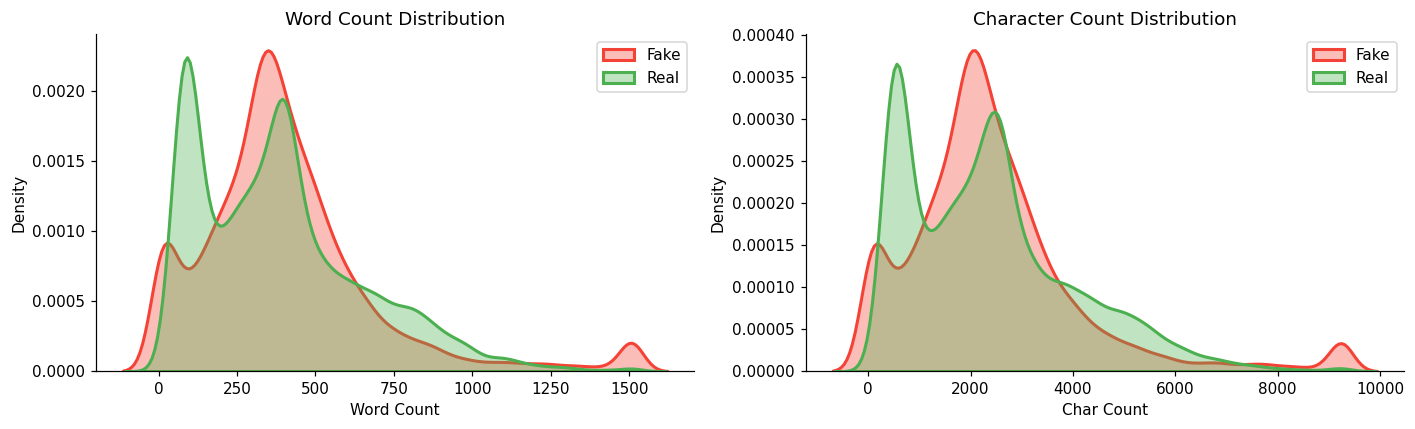

In [4]:
df["char_count"] = df["text"].str.len()
df["word_count"] = df["text"].str.split().str.len()

print("── Character count ─────────────────────────────────")
print(df.groupby("label")["char_count"].describe().rename(index={0:"Real",1:"Fake"}).to_string())
print("\n── Word count ──────────────────────────────────────")
print(df.groupby("label")["word_count"].describe().rename(index={0:"Real",1:"Fake"}).to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col, title in zip(
    axes,
    ["word_count", "char_count"],
    ["Word Count Distribution", "Character Count Distribution"]
):
    for lbl, color, name in [(1, "#F44336", "Fake"), (0, "#4CAF50", "Real")]:
        subset = df[df["label"] == lbl][col].clip(upper=df[col].quantile(0.99))
        sns.kdeplot(subset, ax=ax, label=name, color=color, fill=True, alpha=0.35, linewidth=2)
    ax.set_title(title, fontsize=12)
    ax.legend()
    ax.set_xlabel(col.replace("_", " ").title())
    ax.set_ylabel("Density")

plt.tight_layout()
plt.show()

## 4. Subject / Category Breakdown

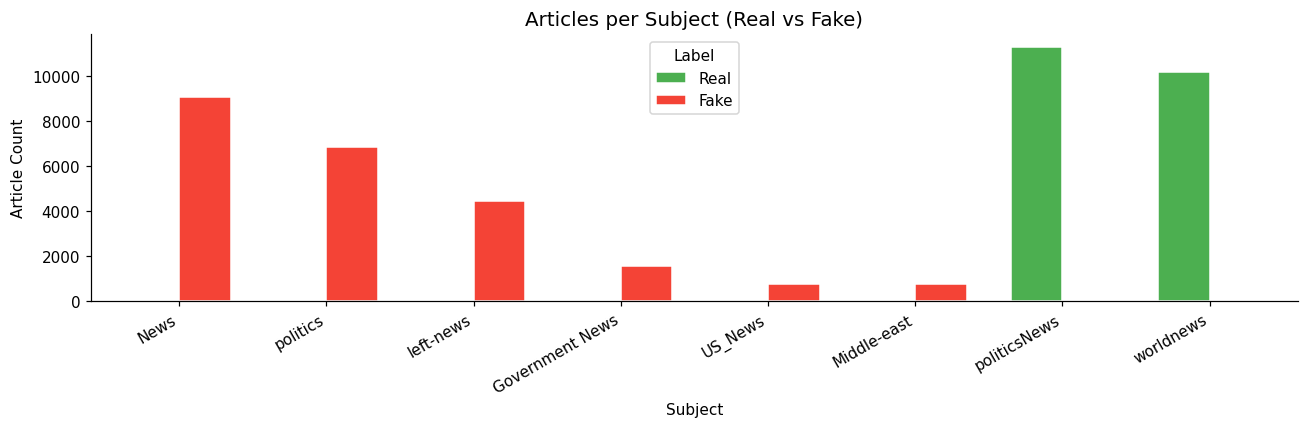

label             Real  Fake
subject                     
News                 0  9050
politics             0  6841
left-news            0  4459
Government News      0  1570
US_News              0   783
Middle-east          0   778
politicsNews     11272     0
worldnews        10145     0


In [5]:
if "subject" in df.columns:
    subject_label = (
        df.groupby(["subject", "label"])
          .size()
          .unstack(fill_value=0)
          .rename(columns={0: "Real", 1: "Fake"})
    )
    subject_label = subject_label.sort_values("Fake", ascending=False)
    subject_label.plot(
        kind="bar", figsize=(12, 4),
        color=["#4CAF50", "#F44336"],
        edgecolor="white", width=0.7,
    )
    plt.title("Articles per Subject (Real vs Fake)", fontsize=13)
    plt.xlabel("Subject")
    plt.ylabel("Article Count")
    plt.xticks(rotation=30, ha="right")
    plt.legend(title="Label")
    plt.tight_layout()
    plt.show()
    print(subject_label)
else:
    print("No 'subject' column found in this dataset.")

## 5. Word Frequency & Word Clouds

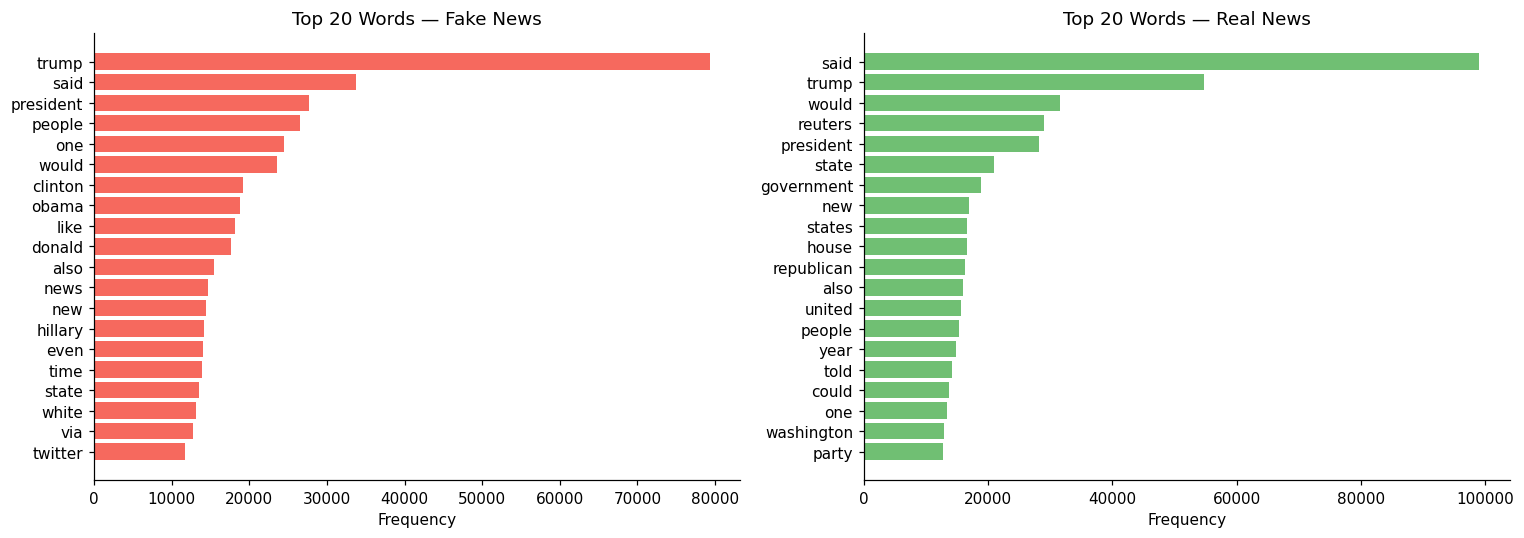

In [6]:
import re
from nltk.corpus import stopwords
import nltk
nltk.download("stopwords", quiet=True)
STOP = set(stopwords.words("english"))

def get_top_words(texts, n=20):
    words = re.findall(r'\b[a-z]{3,}\b', " ".join(texts).lower())
    words = [w for w in words if w not in STOP]
    return Counter(words).most_common(n)

fake_texts = df[df["label"] == 1]["text"].dropna().tolist()
real_texts = df[df["label"] == 0]["text"].dropna().tolist()

fake_top = get_top_words(fake_texts)
real_top = get_top_words(real_texts)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, top_words, title, color in zip(
    axes,
    [fake_top, real_top],
    ["Top 20 Words — Fake News", "Top 20 Words — Real News"],
    ["#F44336", "#4CAF50"],
):
    words_list, freqs = zip(*top_words)
    y_pos = range(len(words_list))
    ax.barh(y_pos, freqs, color=color, alpha=0.8)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(words_list)
    ax.invert_yaxis()
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Frequency")

plt.tight_layout()
plt.show()

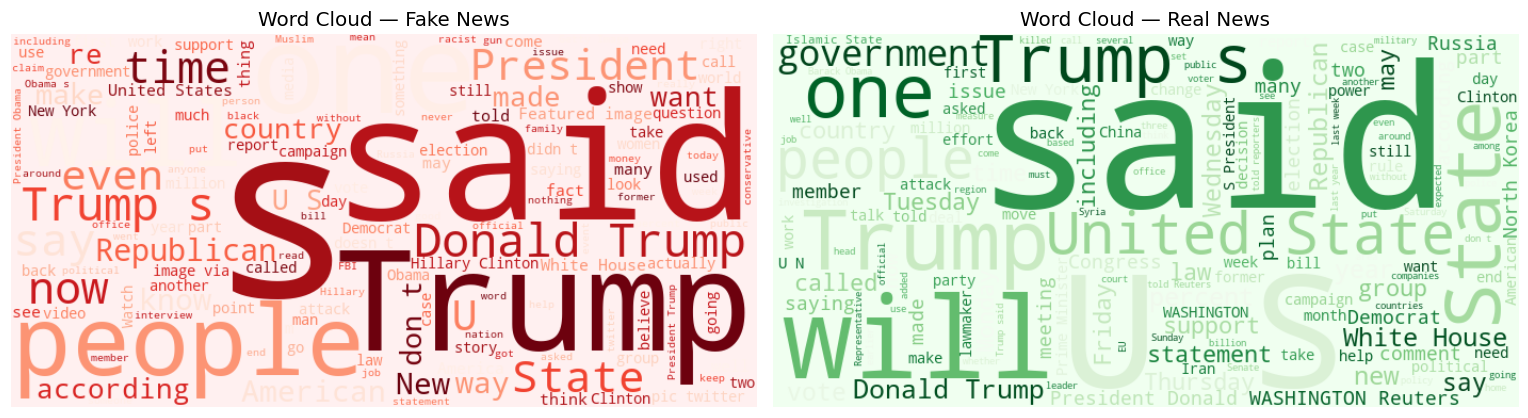

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, texts, title, bg in zip(
    axes,
    [fake_texts, real_texts],
    ["Word Cloud — Fake News", "Word Cloud — Real News"],
    ["#fff0f0", "#f0fff0"],
):
    all_text = " ".join(texts[:3000])   # sample for speed
    wc = WordCloud(
        width=700, height=350,
        background_color=bg,
        colormap="Reds" if "Fake" in title else "Greens",
        max_words=150,
    ).generate(all_text)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(title, fontsize=13)

plt.tight_layout()
plt.show()

## 6. Preprocessing Preview

In [9]:
df_clean = preprocess_dataframe(df)

print("── Before preprocessing (first 300 chars) ──────────────")
print(df_clean["text"].iloc[0][:300])
print("\n── After preprocessing ─────────────────────────────────")
print(df_clean["clean_text"].iloc[0][:300])

print(f"\nAvg tokens before : {df_clean['word_count'].mean():.1f}")
df_clean["clean_word_count"] = df_clean["clean_text"].str.split().str.len()
print(f"Avg tokens after  : {df_clean['clean_word_count'].mean():.1f}")
print(f"Vocabulary reduction : {(1 - df_clean['clean_word_count'].mean()/df_clean['word_count'].mean())*100:.1f}%")

716 articles resulted in empty clean_text.


── Before preprocessing (first 300 chars) ──────────────
21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some Hollywood fame appearing in TV shows and films such as Ferris Bueller s Day Off) made some provocative statements on Judge Jeanine Pirro s show recently. While discussing the halt that was imposed on Pres

── After preprocessing ─────────────────────────────────
centuri wire say ben stein reput professor pepperdin univers also hollywood fame appear show film ferri bueller day made provoc statement judg jeanin pirro show recent discuss halt impos presid trump execut order travel stein refer judgement circuit court washington state coup tat execut branch cons

Avg tokens before : 405.3
Avg tokens after  : 229.4
Vocabulary reduction : 43.4%


## 7. Key Findings Summary

**EDA Takeaways for Week 1:**

| Observation | Detail |
|---|---|
| **Dataset size** | ~44 000 articles (Fake + Real) |
| **Class balance** | Near 50/50 → no oversampling needed |
| **Text length** | Fake articles tend to be shorter on average |
| **Top words** | High overlap → TF-IDF weighting important |
| **Vocabulary** | After preprocessing, ~50–60 % vocabulary reduction |
| **Next step** | Train TF-IDF + Logistic Regression baseline → `main.py` |